In [3]:
!unzip -q captcha_data.zip

replace train-labels.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

# Distorted Visual Pattern Recognition
**By:** Harman Saini

## Methodology & Workflow
The objective of this project is to build a deep learning model that  can correctly recognize and
reconstruct text sequences from visually distorted grayscale images. The workflow consists of an asynchronous data pipeline, a Convolutional Recurrent Neural Network (CRNN) for feature extraction and sequence modeling, and Connectionist Temporal Classification (CTC) loss to handle dynamic character alignment.

## Importing Libraries and Making the Code Reproducible

Importing necessary libraries for the workflow

To make the notebook reproducible, a fixed random seed is used for Python, NumPy, and TensorFlow. The train-validation split is also fixed using `random_state=42`. TensorFlow deterministic operations are enabled where possible so that repeated runs produce nearly consistent results.

In [4]:
#importing important libraries and making the code reproducible
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import random
import tensorflow as tf
import sklearn
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

tf.keras.utils.set_random_seed(SEED)

try:
    tf.config.experimental.enable_op_determinism()
except:
    pass


## Dataset Overview

The training data contains grayscale distorted sequence images and their corresponding text labels.  
The test data contains only distorted images, for which the model must generate predicted character sequences.



In [7]:
#reading data and directories

# please change these directories accordingly
df = pd.read_csv("/content/train-labels.csv")
TRAIN_IMG_DIR = "/content/train_images"
TEST_IMG_DIR = "/content/test_images"

df['full_path'] = df['image'].apply(lambda x: os.path.join(TRAIN_IMG_DIR, x))



## Sample Training Images

Before training the model, a few training images are visualized to understand the nature of the dataset.  
The images contain distorted grayscale text sequences with noise, irregular spacing, shape deformation, and overlapping characters.


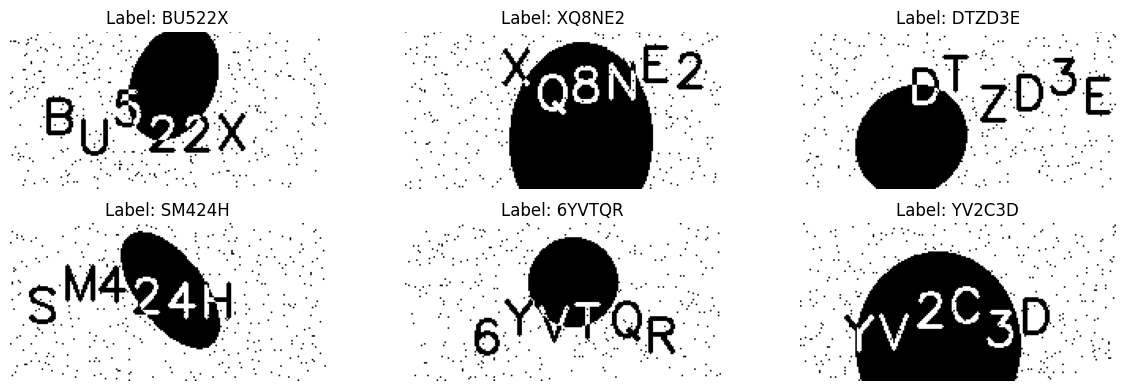

In [8]:
plt.figure(figsize=(12, 4))

for i in range(6):
    img_path = df["full_path"].iloc[i]

    img = tf.io.read_file(img_path)
    img = tf.image.decode_image(
        img,
        channels=1,
        expand_animations=False
    )

    plt.subplot(2, 3, i + 1)
    plt.imshow(tf.squeeze(img), cmap="gray")
    plt.title(f"Label: {df['text'].iloc[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## Character-Level Label Encoding

Since the task is to predict a sequence of characters, the text labels are encoded at the character level.  
Each unique character in the training labels is assigned a unique integer index using a character-level tokenizer.

The encoded labels are then padded with zeros so that all labels have the same length inside a batch. This is required because neural networks process data in fixed-size tensor batches.

The number of output classes is calculated by including all unique characters along with an additional blank token required by CTC loss.

In [9]:
#using Tokenizer to tokenize  characters used in the train data
tokenizer = Tokenizer(char_level=True, filters='',lower=False)

#fitting our tokenizer to the characters of our training data
tokenizer.fit_on_texts(df['text'].values)

#generating the sequential form of data with it
sequences = tokenizer.texts_to_sequences(df['text'].values)

#finding the maximum length of the sequence so that we can do padding accordingly
max_label_len = max(df['text'].apply(len))

#doing zero padding to make the vectors of same dimensions
padded_labels = pad_sequences(sequences, maxlen=max_label_len, padding='post')

#here we are adding 2 to num_classes because i)zero index for the padded tokens
#ii)this is for the blank token which is used by ctc to separate the repeating characters
num_classes = len(tokenizer.word_index) + 2

#splitting the train and validation dataset
X_train_paths, X_val_paths, y_train, y_val = train_test_split(df['full_path'].values, padded_labels, test_size=0.1, random_state=42,shuffle=True)



## Data Pipeline & Preprocessing
To ensure fast training and prevent GPU bottlenecking, a highly optimized `tf.data` pipeline was built.
* **Preprocessing:** Images are converted to grayscale, normalized to [0,1], and resized to (32, 128). The axes are transposed to `(Width, Height, Channels)` to align with the RNN's horizontal timesteps.
* **Augmentation:** Random brightness, contrast, and static noise are added to make the model robust against Captcha distortions.
* **Optimization:** `AUTOTUNE` prefetching is used to decode images dynamically in the background.

In [10]:

#function for Training images(with  data augmentation)
def map_train_images(image_path, label):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_image(img, channels=1, expand_animations=False)
    img = tf.image.convert_image_dtype(img, tf.float32)

    #data augmentation
    #randomly change brightness
    img = tf.image.random_brightness(img, max_delta=0.2)

    #randomly change contrast
    img = tf.image.random_contrast(img, lower=0.8, upper=1.2)

    #add random static/noise to the background
    noise = tf.random.normal(shape=tf.shape(img), mean=0.0, stddev=0.05, dtype=tf.float32)
    img = img + noise

    #ensure pixel values don't break the 0.0 to 1.0 rule after adding noise
    img = tf.clip_by_value(img, 0.0, 1.0)
    #now resizing the image

    img = tf.image.resize(img, [32, 128])
    #now transposing the image so that our rnn(bilstm) moves along the width of the image (timesteps)
    img = tf.transpose(img, perm=[1, 0, 2])
    return img, label


#function for validation images(no data augmentation as we are testing on it)
def map_val_images(image_path, label):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_image(img, channels=1, expand_animations=False)
    img = tf.image.convert_image_dtype(img, tf.float32)
    img = tf.image.resize(img, [32, 128])
    img = tf.transpose(img, perm=[1, 0, 2])
    return img, label

#apply the train function (with  data augmentation)

#avoided to train with X_train ,y_train as that was creating memory error ,
#we will pass on strings of path which will further trained in batches of 64
train_dataset = tf.data.Dataset.from_tensor_slices((X_train_paths, y_train))

#Using map fucntion to apply the train function on whole dataset
processed_train_dataset = train_dataset.map(map_train_images, num_parallel_calls=tf.data.AUTOTUNE)

#maps dataset to (inputs, targets) structure required by Keras.
#inputs are packed into a dict for multi-input architecture; target is None
#because CTC loss is computed internally inside the model layers.
train_dataset = processed_train_dataset.map(lambda image_tensor, label_tensor: ({'image': image_tensor, 'label': label_tensor},None ))

#batching the data for parallel computation
train_dataset = train_dataset.batch(64).prefetch(tf.data.AUTOTUNE)

#apply the val function (pure, clean images)(similar to above)
val_dataset = tf.data.Dataset.from_tensor_slices((X_val_paths, y_val))
processed_val_dataset = val_dataset.map(map_val_images, num_parallel_calls=tf.data.AUTOTUNE)
val_dataset = processed_val_dataset.map(lambda image_tensor, label_tensor: ({'image': image_tensor, 'label': label_tensor},None ))
val_dataset = val_dataset.batch(64).prefetch(tf.data.AUTOTUNE)

## Connectionist Temporal Classification (CTC) Loss

### What is CTC Loss?

Connectionist Temporal Classification (CTC) loss is a specialized loss function used for sequence recognition tasks where the exact alignment between the input and output is unknown.

In this project, the input is a distorted grayscale image containing a sequence of characters. However, we do not know the exact position of each character inside the image. Characters may be shifted, overlapped, stretched, or partially hidden. Because of this, manually segmenting the image into individual characters is difficult.

CTC loss solves this problem by allowing the model to learn the alignment between image features and output characters automatically.

### Why CTC Loss is Used in This Project

After preprocessing, each image is passed through CNN layers to extract visual features. These features are then reshaped into sequential timesteps along the horizontal direction of the image. Each timestep represents a vertical slice of visual information from the distorted text image.

The BiLSTM layers process these timesteps and predict a probability distribution over possible characters at each timestep. Since the number of timesteps is usually larger than the number of actual characters in the label, CTC loss is used to map these timestep-level predictions to the final character sequence.

### How CTC Loss Works

CTC introduces a special blank token. This blank token helps the model represent positions where no character is present. It also helps handle repeated characters.

For example, the model may produce an intermediate sequence like:

A - A X X - U 3 3 - 2

where `-` represents the blank token. CTC decoding removes blanks and repeated characters where appropriate to produce the final output sequence.

### Purpose of CTC Loss

CTC loss is useful in this project because it allows the model to:

- Recognize distorted text without explicit character-level segmentation.
- Handle variable-length character sequences.
- Learn the alignment between image regions and output characters automatically.
- Train the CNN-BiLSTM model end-to-end.
- Decode the final ordered character sequence from timestep-level predictions.

Therefore, CTC loss is suitable for this distorted visual sequence recognition task because the model only needs image-level labels, not manually annotated character positions.

In [11]:
#we subclass tf.keras.layers.Layer to create a custom layer that computes the
#CTC loss internally during training.

class CTCLayer(layers.Layer):
    def __init__(self, name=None):
        super().__init__(name=name)
        # Using the built-in Keras backend CTC batch cost function
        self.loss_fn = tf.keras.backend.ctc_batch_cost

    def call(self, y_true, y_pred):
        #y_true: The actual text labels (padded integer sequences)
        #y_pred: The model's raw probability predictions (softmax output)

        #get the current batch size dynamically
        batch_len = tf.cast(tf.shape(y_true)[0], dtype="int64")

        # Get the number of timesteps produced by the RNN output.
        # In this model, the output has 32 timesteps.
        input_length = tf.cast(tf.shape(y_pred)[1], dtype="int64")

        #calculate the actual length of each text label, ignoring the '0' padding tokens.
        #this tells the CTC loss exactly how many real characters it needs to align.
        label_length = tf.reduce_sum(tf.cast(tf.not_equal(y_true, 0), tf.int64), axis=-1, keepdims=True)

        #create an array stating that every image in the batch uses all timesteps
        input_length = input_length * tf.ones(shape=(batch_len, 1), dtype="int64")

        #compute the raw CTC loss for the batch
        loss = self.loss_fn(y_true, y_pred, input_length, label_length)

        #average the loss across the batch to keep the numbers stable and readable
        # (e.g., prevents the loss from displaying as massive numbers like 1300)
        self.add_loss(tf.reduce_mean(loss))

        #the layer simply passes the predictions forward during inference
        return y_pred

## Model Architecture
The model uses a CRNN architecture:
* **CNN Block:** Three Convolutional layers with Batch Normalization and MaxPooling extract visual features. After convolution and pooling, the feature map is reshaped into 32 sequential timesteps. Each timestep represents a vertical slice of visual features from the image, allowing the BiLSTM layers to learn the left-to-right character sequence.
* **RNN Block:** Two Bidirectional LSTMs (128 and 64 units) read the visual slices left-to-right and right-to-left, gaining full context of overlapping letters.
* **CTC Loss:** A custom CTC layer mathematically aligns the unsegmented image slices with the true text labels using a dedicated Blank Token.

In [12]:
#Creating the architecture of the model
#define the input layer for the image tensors
#The shape is set as (Width=128, Height=32, Channels=1)
#the axes are intentionally transposed so that the Width dimension maps directly
#to the RNN's "time dimension", allowing the LSTM to scan the text left-to-right
input_img = layers.Input(shape=(128, 32, 1), name="image", dtype="float32")

#define the input layer for the target text labels
#shape is set to (None,) to allow for variable-length character token sequences,
#which is natively supported and decoded dynamically by the CTC loss function
labels = layers.Input(name="label", shape=(None,), dtype="int32")

#CNN with Batch Normalization (for full word prediction)
#convolution layer
x = layers.Conv2D(32, (3, 3), padding="same")(input_img)

#batch normalization
x = layers.BatchNormalization()(x)

#activation function
x = layers.Activation("relu")(x)

#max pooling
x = layers.MaxPooling2D((2, 2))(x)

x = layers.Conv2D(64, (3, 3), padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)
x = layers.MaxPooling2D((2, 2))(x)

x = layers.Conv2D(128, (3, 3), padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)
x = layers.MaxPooling2D((1, 2))(x)

x = layers.Reshape(target_shape=(32, 4 * 128))(x)
x = layers.Dense(64, activation="relu")(x)

#dropout layers(helps preventing overfitting)
x = layers.Dropout(0.2)(x)

#using Birdirectional LSTM
x = layers.Bidirectional(layers.LSTM(128, return_sequences=True))(x)
x = layers.Bidirectional(layers.LSTM(64, return_sequences=True))(x)

#using neuron layer
preds = layers.Dense(num_classes, activation="softmax", name="preds")(x)
output = CTCLayer(name="ctc_loss")(labels, preds)

model = models.Model(inputs=[input_img, labels], outputs=output)
prediction_model = models.Model(inputs=input_img, outputs=preds)

#AMSGrad is used with Adam to help stabilize optimization during CTC training
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001, amsgrad=True))
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)  │ (None, 128, 32,   │          0 │ -                 │
│                     │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 32,   │        320 │ image[0][0]       │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 32,   │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 128, 32,   │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 16,    │          0 │ activation[0][0]  │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 64, 16,    │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 16,    │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 64, 16,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 8, 64) │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 32, 8,     │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 8,     │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 32, 8,     │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 32, 4,     │          0 │ activation_2[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 32, 512)   │          0 │ max_pooling2d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 32, 64)    │     32,832 │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 32, 64)    │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 32, 256)   │    197,632 │ dropout[0][0]     │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 32, 128)   │    164,352 │ bidirectional[0]

 Total params: 493,544 (1.88 MB)

 Trainable params: 493,096 (1.88 MB)

 Non-trainable params: 448 (1.75 KB)

## Training Strategy
The model is compiled using the **Adam optimizer with AMSGrad** enabled. AMSGrad was used to make the optimization process more stable during CTC-based sequence training.       
* **EarlyStopping:** Halts training if the validation loss stops improving for 5 epochs.
* **ReduceLROnPlateau** Reduces the learning rate when validation loss stops improving, helping the model fine-tune its weights more carefully.
* **ModelCheckpoint:** Ensures only the weights with the lowest validation loss are saved.

In [13]:
#training part

callbacks = [#EarlyStopping prevent the model from training if loss is not decreasing
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),

    #ReduceLROnPlateau reduces the learning rate when loss does not improve
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-5),

    #ModelCheckpoint saves the model weights with the lowest validation loss
    tf.keras.callbacks.ModelCheckpoint("best_model.keras",monitor="val_loss",save_best_only=True,mode="min",verbose=1)
]
model.fit(train_dataset, validation_data=val_dataset, epochs=30, callbacks=callbacks)



Epoch 1/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - loss: 26.5021
Epoch 1: val_loss improved from None to 22.35202, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
282/282 ━━━━━━━━━━━━━━━━━━━━ 58s 164ms/step - loss: 23.2142 - val_loss: 22.3520 - learning_rate: 0.0010
Epoch 2/30
281/282 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - loss: 22.3278
Epoch 2: val_loss did not improve from 22.35202
282/282 ━━━━━━━━━━━━━━━━━━━━ 39s 138ms/step - loss: 22.2444 - val_loss: 23.0893 - learning_rate: 0.0010
Epoch 3/30
281/282 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - loss: 20.6897
Epoch 3: val_loss improved from 22.35202 to 19.84076, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
282/282 ━━━━━━━━━━━━━━━━━━━━ 37s 130ms/step - loss: 18.4934 - val_loss: 19.8408 - learning_rate: 0.0010
Epoch 4/30
281/282 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - loss: 8.1746
Epoch 4: val_loss improved from 19.84076 to 3.36673, saving model to best_model.keras



## Experimentation and Problem Solving
Throughout the development of this model, several approaches were tested and refined to achieve this present result:

1. **Overcoming RAM Exhaustion (The Memory Error):** Initially, I attempted to load the entire `X_train` and `y_train` dataset directly into memory. This caused an immediate out-of-memory (OOM) crash. I solved this by redesigning the pipeline to use the `tf.data.Dataset` API, passing only file paths and decoding the images dynamically in batches.
2. **Handling Overfitting:** My earlier model memorized the training data quickly but performed poorly on validation. To fix this, I introduced Dropout layers (0.2) in the Dense network.
3. **Data Augmentation:** I further added random brightness, contrast, and noise injection to improve robustness against distorted and noisy inputs.
4. **Optimizer Selection:** Initially, I used the standard Adam optimizer, but the validation loss showed unstable fluctuations during training. Therefore, I switched to the AMSGrad variant of Adam by setting `amsgrad=True`. AMSGrad helped make the optimization process more stable and reduced sudden loss fluctuations.
5. **CTC Implementation Choice:**  I also experimented with computing CTC loss as a separate loss function in `model.compile()`. However, in my experiments, the custom CTC layer implementation gave better validation performance and more stable results. Therefore, I retained the CTC layer approach in the final model. This also kept the training pipeline organized, because the CTC layer directly receives the true labels and predicted character probabilities and computes the loss inside the model graph.

In [14]:
#evaluation pipeline
#similar to that of training one but without the data augmentation
def map_test_images(image_path):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_image(img, channels=1, expand_animations=False)
    img = tf.image.convert_image_dtype(img, tf.float32)
    img = tf.image.resize(img, [32, 128])
    img = tf.transpose(img, perm=[1, 0, 2])
    return img

#creating the test dataset similar to the training one
test_image_files = sorted(os.listdir(TEST_IMG_DIR))
test_paths = [os.path.join(TEST_IMG_DIR, fname) for fname in test_image_files]
test_dataset = tf.data.Dataset.from_tensor_slices(test_paths)
test_dataset = test_dataset.map(map_test_images, num_parallel_calls=tf.data.AUTOTUNE).batch(64)

raw_predictions = prediction_model.predict(test_dataset)



79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step


##  Evaluation and Outputs
During inference, the model outputs a probability matrix across 32 timesteps. **Greedy Decoding** is used to extract the highest probability characters, collapse consecutive duplicates, and remove CTC blank tokens.
Finally, the Character Error Rate (CER) is calculated using Levenshtein Distance to measure the exact edit distance between predictions and ground truths.

In [ ]:
#function to decode raw model probability distributions (logits) into human-readable text strings
#using Connectionist Temporal Classification (CTC) greedy decoding.
def decode_batch_predictions(pred, tokenizer):

    # Create a 1D array containing the full sequence length.
    # Here, pred.shape[1] represents the number of timesteps, which is 32 for this model.
    #for every individual sample in the current batch.
    input_len = np.ones(pred.shape[0]) * pred.shape[1]

    #apply CTC Greedy Decoding to collapse consecutive identical characters and eliminate
    #the special CTC blank tokens. [0][0] extracts the primary sparse tensor of predicted token IDs.
    results = tf.keras.backend.ctc_decode(pred, input_length=input_len, greedy=True)[0][0]

    #perform a reverse lookup mapping by inverting the tokenizer's dictionary
    #from {character: integer_token} to {integer_token: character}.
    inverted_word_index = {v: k for k, v in tokenizer.word_index.items()}

    output_texts = []
    #iterate through the decoded integer token sequences sample by sample
    for res in results:
        #convert the TensorFlow tensor into a standard NumPy array for evaluation
        res = res.numpy()

        #translate each token back to a letter using the inverted index, skipping
        #non-positive tokens (like -1 used for sequence padding), and join them into a word string.
        current_text = "".join([inverted_word_index[num] for num in res if num > 0 and num in inverted_word_index])
        output_texts.append(current_text)

    return output_texts

#decoding the raw probability matrices obtained during model inference into strings
predicted_strings = decode_batch_predictions(raw_predictions, tokenizer)

#making submission file in pandas dataframe
submission_df = pd.DataFrame({'image': test_image_files, 'prediction': predicted_strings})

submission_df.to_csv("submission_Harman_Saini.csv", index=False)

In [16]:
#re-extract the true text labels for the validation set using your random seed

_, val_texts = train_test_split(df['text'].values, test_size=0.1, random_state=42)

#set up a clean validation dataset pipeline for predictions
val_img_dataset = tf.data.Dataset.from_tensor_slices(X_val_paths)
val_img_dataset = val_img_dataset.map(map_test_images, num_parallel_calls=tf.data.AUTOTUNE).batch(64)

#generate raw predictions and decode them into strings
raw_val_predictions = prediction_model.predict(val_img_dataset)
predicted_val_strings = decode_batch_predictions(raw_val_predictions, tokenizer)

#CER function (Levenshtein Distance)
def compute_levenshtein_distance(s1, s2):
    #Calculates the minimum edit distance (insertions, deletions, substitutions) between two strings.
    if len(s1) < len(s2):
        return compute_levenshtein_distance(s2, s1)
    if len(s2) == 0:
        return len(s1)

    previous_row = range(len(s2) + 1)
    for i, c1 in enumerate(s1):
        current_row = [i + 1]
        for j, c2 in enumerate(s2):
            insertions = previous_row[j + 1] + 1
            deletions = current_row[j] + 1
            substitutions = previous_row[j] + (c1 != c2)
            current_row.append(min(insertions, deletions, substitutions))
        previous_row = current_row
    return previous_row[-1]

#evaluation
total_edit_distance = 0
total_character_count = 0
perfect_matches = 0

for true_str, pred_str in zip(val_texts, predicted_val_strings):

    # Calculate character edits required
    distance = compute_levenshtein_distance(true_str, pred_str)
    total_edit_distance += distance
    total_character_count += len(true_str)

    if distance == 0:
        perfect_matches += 1

# Calculate final percentages
character_error_rate = (total_edit_distance / total_character_count) * 100
sequence_accuracy = (perfect_matches / len(val_texts)) * 100

print(f"Character Error Rate (CER): {character_error_rate:.2f}%")
print(f" Exact Match Word Accuracy:   {sequence_accuracy:.2f}%")
print(f"Total Images Evaluated:       {len(val_texts)}")
#finally model is giving the CER(character error rate):0.68%
#Exact Match Word Accuracy:96.00% on 2000 images(validation set)

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step
Character Error Rate (CER): 0.68%
 Exact Match Word Accuracy:   96.00%
Total Images Evaluated:       2000


## Final Validation Performance

The model achieved the following validation performance on 2000 validation images:

- Character Error Rate (CER): 0.68%
- Exact Match Word Accuracy: 96.00%

A low CER indicates that the model makes very few character-level errors. The high word-level accuracy shows that most complete distorted sequences are predicted correctly.

In [17]:
# Saving the model
prediction_model.save("captcha_prediction_model.keras")